# Application du Machine Learning en Cybersécurité (ML for Cybersecurity)

### Détection d'intrusions : Utilisation d'algorithmes de Machine Learning pour détecter des activités suspicieuses ou des intrusions dans les réseaux.

## (Étape 1 – Chargement initial du dataset NSL-KDD

### 1.1 Installation des bibliothèques nécessaires

In [50]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]


In [1]:
# Install main libraries
!pip install numpy pandas matplotlib seaborn

# Install scikit-learn (includes preprocessing, model selection, metrics, and models)
!pip install scikit-learn

# Install XGBoost
!pip install xgboost

# For Google Colab integration (this will be automatically available in Colab)
# No need to install, but if you want it locally for some reason:
!pip install google-colab

You should consider upgrading via the 'C:\Users\rsica\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'C:\Users\rsica\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'C:\Users\rsica\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'C:\Users\rsica\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.
ERROR: Could not find a version that satisfies the requirement google-colab (from versions: none)
ERROR: No matching distribution found for google-colab
You should consider upgrading via the 'C:\Users\rsica\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


### 1.2 Importation des bibliothèques

In [31]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

# Scikit-learn: preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder

# Scikit-learn: model selection & evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import metrics

# Scikit-learn: models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn import svm

# Scikit-learn: dimensionality reduction
from sklearn.decomposition import PCA

# XGBoost
import xgboost as xgb

# System
import warnings

# Settings
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

# Only in Jupyter notebooks
%matplotlib inline

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SVMSMOTE
from collections import Counter
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt






## GOOGLE-COLAB

In [4]:
# Montage de Google Drive (nécessaire uniquement sur Colab)
from google.colab import drive
drive.mount('/content/drive')

# Importation des bibliothèques système
import os

# Définition du chemin vers le dossier contenant les données
folder_path = '/content/drive/MyDrive/Colab Notebooks/nslkdd'

# Affichage des fichiers présents dans ce dossier
print("Fichiers disponibles dans le dossier :")
print(os.listdir(folder_path))

# Définition du chemin complet vers le fichier de données
file_path = '/content/drive/MyDrive/Colab Notebooks/nslkdd/'

# Chargement du fichier CSV sans en-tête
data_train = pd.read_csv(file_path + "KDDTrain+.txt", header=None)

# Affichage des 5 premières lignes du DataFrame pour vérification
print("\nAperçu des premières lignes du dataset :")
data_train.head()

ModuleNotFoundError: No module named 'google.colab'

### 1.3 Chargement du fichier d'entraînement - JUPYTER NOTEBOOK

In [33]:
file_path = './DATASETS/nslkdd/'
# Charger les données
data_train = pd.read_csv(file_path + "KDDTrain+.txt", header=None)
data_train.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## Ajout des noms de colonnes au dataset NSL-KDD

Le **NSL-KDD** dataset ne contient pas d'en-têtes dans les fichiers bruts.  
Nous devons donc ajouter manuellement les **43 colonnes** correspondant aux caractéristiques du jeu de données.

Ces colonnes décrivent :
- Les caractéristiques du trafic réseau (durée, protocole, service…),
- Des indicateurs statistiques sur les connexions,
- Et deux colonnes cibles :
  - `etiquette` (normal ou attaque),
  - `niveau` (difficulté de l'attaque, de 0 à 21).

Dans cette étape :
- Nous définissons une liste des 43 noms de colonnes.
- Nous ajoutons ces colonnes au DataFrame `data_train`.
- Nous affichons les premières lignes pour vérifier le résultat.

### 1.4 Définition des colonnes du dataset

In [34]:
# Définition des 43 colonnes du jeu de données NSL-KDD
colonnes = [
    'duree',                   # duration
    'type_protocole',         # protocol_type
    'service',                # service
    'drapeau',                # flag
    'octets_source',          # src_bytes
    'octets_destination',     # dst_bytes
    'connexion_locale',       # land
    'fragment_errone',        # wrong_fragment
    'urgent',                 # urgent
    'hot',                    # hot (nombre de commandes suspectes)
    'echecs_connexion',       # num_failed_logins
    'connecte',               # logged_in
    'hotes_compromis',        # num_compromised
    'acces_root',             # root_shell
    'tentatives_su',          # su_attempted
    'nombre_root',            # num_root
    'creations_fichiers',     # num_file_creations
    'acces_shell',            # num_shells
    'acces_fichiers',         # num_access_files
    'commandes_sortantes',    # num_outbound_cmds
    'login_hote',             # is_host_login
    'login_invite',           # is_guest_login
    'compte_connexions',      # count
    'compte_srv',             # srv_count
    'taux_erreurs_s',         # serror_rate
    'taux_erreurs_srv_s',     # srv_serror_rate
    'taux_erreurs_r',         # rerror_rate
    'taux_erreurs_srv_r',     # srv_rerror_rate
    'taux_meme_srv',          # same_srv_rate
    'taux_srv_diff',          # diff_srv_rate
    'taux_hote_srv_diff',     # srv_diff_host_rate
    'compte_hote_dst',        # dst_host_count
    'compte_srv_hote_dst',    # dst_host_srv_count
    'taux_meme_srv_dst',      # dst_host_same_srv_rate
    'taux_srv_diff_dst',      # dst_host_diff_srv_rate
    'taux_same_src_port_dst', # dst_host_same_src_port_rate
    'taux_srv_diff_hote_dst', # dst_host_srv_diff_host_rate
    'taux_erreur_s_dst',      # dst_host_serror_rate
    'taux_erreur_srv_s_dst',  # dst_host_srv_serror_rate
    'taux_erreur_r_dst',      # dst_host_rerror_rate
    'taux_erreur_srv_r_dst',  # dst_host_srv_rerror_rate
    'etiquette',              # outcome
    'niveau'                  # level
]

# Attribution des colonnes au DataFrame data_train
data_train.columns = colonnes

### 1.5 Aperçu des premières lignes

In [35]:
print("Aperçu des premières lignes du dataset :")
data_train.head()

Aperçu des premières lignes du dataset :


,duree,type_protocole,service,drapeau,octets_source,octets_destination,connexion_locale,fragment_errone,urgent,hot,echecs_connexion,connecte,hotes_compromis,acces_root,tentatives_su,nombre_root,creations_fichiers,acces_shell,acces_fichiers,commandes_sortantes,login_hote,login_invite,compte_connexions,compte_srv,taux_erreurs_s,taux_erreurs_srv_s,taux_erreurs_r,taux_erreurs_srv_r,taux_meme_srv,taux_srv_diff,taux_hote_srv_diff,compte_hote_dst,compte_srv_hote_dst,taux_meme_srv_dst,taux_srv_diff_dst,taux_same_src_port_dst,taux_srv_diff_hote_dst,taux_erreur_s_dst,taux_erreur_srv_s_dst,taux_erreur_r_dst,taux_erreur_srv_r_dst,etiquette,niveau
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## Étape 2 – Catégorisation des types d’attaque dans le dataset

### 2.1 Regroupement des attaques

In [36]:
# Dictionnaire de regroupement des attaques
attack_category = {
    'normal': 'normal',

    # DoS (Denial of Service)
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS', 'smurf': 'DoS', 'teardrop': 'DoS',
    'apache2': 'DoS', 'udpstorm': 'DoS', 'processtable': 'DoS',

    # Probe (Reconnaissance / Scan de ports)
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',

    # U2R (User to Root - escalade de privilèges)
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R', 'xterm': 'U2R', 'ps': 'U2R',
    'sqlattack': 'U2R',

    # R2L (Remote to Local - accès non autorisé)
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'phf': 'R2L', 'multihop': 'R2L',
    'warezmaster': 'R2L', 'warezclient': 'R2L', 'spy': 'R2L', 'xlock': 'R2L', 'xsnoop': 'R2L',
    'sendmail': 'R2L', 'named': 'R2L', 'snmpgetattack': 'R2L', 'snmpguess': 'R2L',
    'httptunnel': 'R2L', 'worm': 'R2L'
}

# Mapping dans une nouvelle colonne
data_train['type_attaque'] = data_train['etiquette'].map(attack_category)


### 2.2 Affichage de la distribution des attaques

In [37]:
# Affichage des occurrences de chaque type d'attaque
print("Répartition des types d'attaques :")
print(data_train['type_attaque'].value_counts())

Répartition des types d'attaques :
type_attaque
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


### 2.3 Visualisation de la distribution

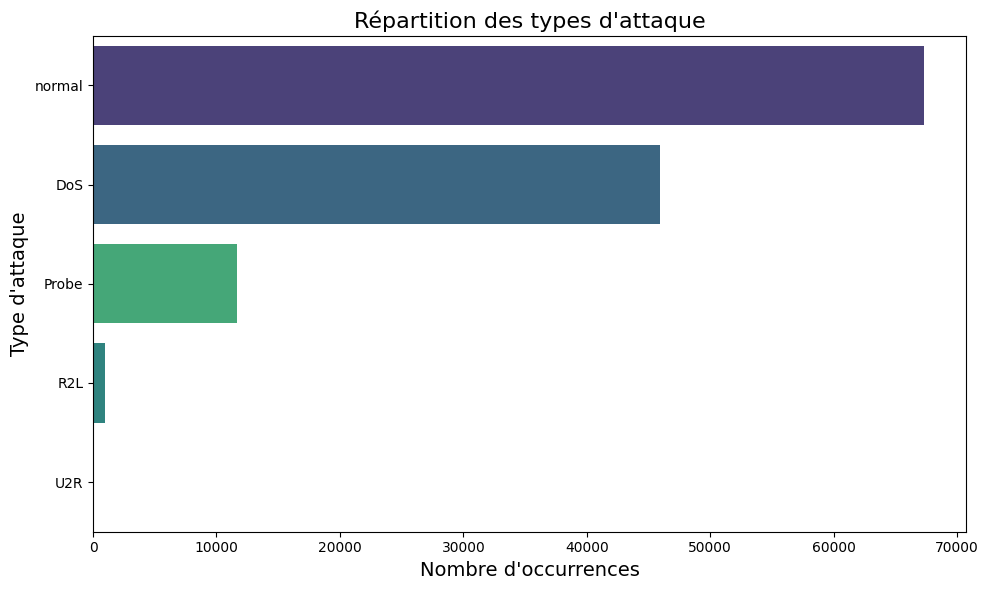

In [38]:
plt.figure(figsize=(10,6))
sns.countplot(data=data_train,
              y='type_attaque',
              hue='type_attaque',
              order=data_train['type_attaque'].value_counts().index,
              palette="viridis",
              legend=False)
plt.title("Répartition des types d'attaque", fontsize=16)
plt.xlabel("Nombre d'occurrences", fontsize=14)
plt.ylabel("Type d'attaque", fontsize=14)
plt.tight_layout()
plt.show()


### Répartition du protocole (type_protocole) par type d’attaque

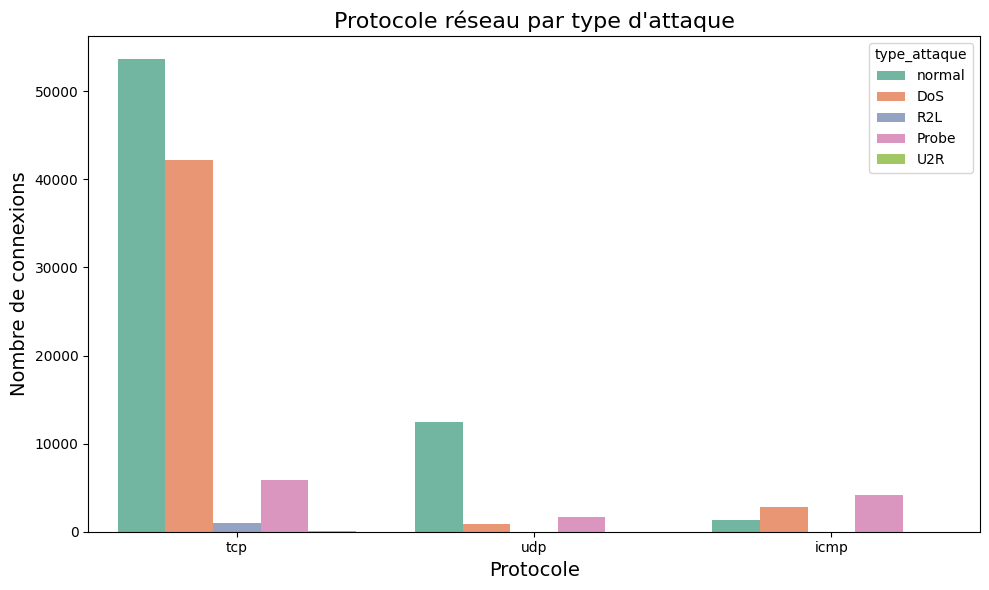

In [39]:
plt.figure(figsize=(10,6))
sns.countplot(data=data_train, x='type_protocole', hue='type_attaque', palette='Set2')
plt.title("Protocole réseau par type d'attaque", fontsize=16)
plt.xlabel("Protocole", fontsize=14)
plt.ylabel("Nombre de connexions", fontsize=14)
plt.tight_layout()
plt.show()


In [40]:
Boîte à moustaches (boxplot) des octets envoyés par type d’attaque

SyntaxError: invalid character '’' (U+2019) (328395003.py, line 1)

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data_train, x='type_attaque', y='octets_source', palette='coolwarm')
plt.title("Distribution des octets source par type d'attaque", fontsize=16)
plt.xlabel("Type d'attaque", fontsize=14)
plt.ylabel("Octets envoyés par la source", fontsize=14)
plt.yscale('log')  # utile si les valeurs varient beaucoup
plt.tight_layout()
plt.show()

### Nuage de points (scatter plot) entre compte_connexions et compte_srv

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=data_train, x='compte_connexions', y='compte_srv', hue='type_attaque', alpha=0.5)
plt.title("Corrélation entre compte_connexions et compte_srv", fontsize=16)
plt.xlabel("compte_connexions", fontsize=14)
plt.ylabel("compte_srv", fontsize=14)
plt.tight_layout()
plt.show()


### 4. Carte de chaleur de corrélation entre les variables numériques

In [ ]:
# Sélection de quelques variables numériques pour éviter une matrice trop grande
features_corr = data_train[['octets_source', 'octets_destination', 'compte_connexions',
                            'compte_srv', 'taux_erreurs_s', 'taux_erreurs_srv_s',
                            'taux_meme_srv', 'taux_srv_diff']]

plt.figure(figsize=(10,8))
sns.heatmap(features_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Carte de chaleur des corrélations entre variables", fontsize=16)
plt.tight_layout()
plt.show()


## Étape 3 – Prétraitement des données
L'objectif ici est de rendre les données exploitables par les modèles de machine learning. Nous allons :

Étapes à suivre :
- Séparer les features et les étiquettes

- Encoder les variables catégorielles (type_protocole, service, drapeau)

- Normaliser les variables numériques

- Sauvegarder les données prétraitées (optionnel mais conseillé)



### 3.1 Séparation des variables (features et labels)

In [ ]:
# Copie du dataset
df = data_train.copy()

# Variables indépendantes (features)
X = df.drop(columns=['etiquette', 'niveau', 'type_attaque'])

# Variable cible (labels à prédire)
y = df['type_attaque']


### 3.2 Encodage des variables catégorielles

Ici, nous utilisons LabelEncoder pour simplifier, mais OneHotEncoder ou LabelCountEncoder sont aussi possibles selon le besoin.

In [ ]:
# Encodage de chaque variable catégorielle
for col in ['type_protocole', 'service', 'drapeau']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])


 ### 3.3 Normalisation des données numériques
 Utilisation de la standardisation (moyenne = 0, écart-type = 1) :

In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Conversion en DataFrame (optionnel)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


### 3.4 Vérification

In [42]:
print("Dimensions de X :", X_scaled.shape)
print("Exemples de données normalisées :")
X_scaled.head()


Dimensions de X : (125973, 41)
Exemples de données normalisées :


,duree,type_protocole,service,drapeau,octets_source,octets_destination,connexion_locale,fragment_errone,urgent,hot,echecs_connexion,connecte,hotes_compromis,acces_root,tentatives_su,nombre_root,creations_fichiers,acces_shell,acces_fichiers,commandes_sortantes,login_hote,login_invite,compte_connexions,compte_srv,taux_erreurs_s,taux_erreurs_srv_s,taux_erreurs_r,taux_erreurs_srv_r,taux_meme_srv,taux_srv_diff,taux_hote_srv_diff,compte_hote_dst,compte_srv_hote_dst,taux_meme_srv_dst,taux_srv_diff_dst,taux_same_src_port_dst,taux_srv_diff_hote_dst,taux_erreur_s_dst,taux_erreur_srv_s_dst,taux_erreur_r_dst,taux_erreur_srv_r_dst
0,-0.110249,-0.124706,-0.686785,0.751111,-0.007679,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,-0.809262,-0.011664,-0.036652,-0.024437,-0.012385,-0.02618,-0.01861,-0.041221,0.0,-0.002817,-0.097531,-0.717045,-0.354343,-0.637209,-0.631929,-0.374362,-0.374432,0.771283,-0.349683,-0.374560,-0.324063,-0.818890,-0.782367,-0.280282,0.069972,-0.289103,-0.639532,-0.624871,-0.224532,-0.376387
1,-0.110249,2.219312,0.781428,0.751111,-0.007737,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,-0.809262,-0.011664,-0.036652,-0.024437,-0.012385,-0.02618,-0.01861,-0.041221,0.0,-0.002817,-0.097531,-0.620982,-0.368110,-0.637209,-0.631929,-0.374362,-0.374432,-1.321428,0.482201,-0.374560,0.734343,-1.035688,-1.161030,2.736852,2.367737,-0.289103,-0.639532,-0.624871,-0.387635,-0.376387
2,-0.110249,-0.124706,1.087305,-0.736235,-0.007762,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,-0.809262,-0.011664,-0.036652,-0.024437,-0.012385,-0.02618,-0.01861,-0.041221,0.0,-0.002817,-0.097531,0.339648,-0.299273,1.602664,1.605104,-0.374362,-0.374432,-1.389669,0.038529,-0.374560,0.734343,-0.809857,-0.938287,-0.174417,-0.480197,-0.289103,1.608759,1.618955,-0.387635,-0.376387
3,-0.110249,-0.124706,-0.442083,0.751111,-0.007723,-0.002891,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,1.235694,-0.011664,-0.036652,-0.024437,-0.012385,-0.02618,-0.01861,-0.041221,0.0,-0.002817,-0.097531,-0.690846,-0.313041,-0.189235,-0.184522,-0.374362,-0.374432,0.771283,-0.349683,-0.374560,-1.533670,1.258754,1.066401,-0.439078,-0.383108,0.066252,-0.572083,-0.602433,-0.387635,-0.345084
4,-0.110249,-0.124706,-0.442083,0.751111,-0.007728,-0.004814,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,1.235694,-0.011664,-0.036652,-0.024437,-0.012385,-0.02618,-0.01861,-0.041221,0.0,-0.002817,-0.097531,-0.472521,0.058678,-0.637209,-0.631929,-0.374362,-0.374432,0.771283,-0.349683,-0.028179,0.734343,1.258754,1.066401,-0.439078,-0.480197,-0.289103,-0.639532,-0.624871,-0.387635,-0.376387


## Étape 4 – Classification binaire (Détection d’intrusion)
Objectif : Prédire si une connexion est normale (0) ou une attaque (1)

### 4.1.1 Création des étiquettes binaires

In [43]:
# Création d'une cible binaire : 0 = normal, 1 = attaque
y_binary = y.copy()
y_binary = y_binary.apply(lambda label: 0 if label == 'normal' else 1)

print("Distribution binaire (0=normal, 1=attaque) :")
print(y_binary.value_counts())

Distribution binaire (0=normal, 1=attaque) :
type_attaque
0    67343
1    58630
Name: count, dtype: int64


 ### 4.1.2 Division du jeu de données

In [44]:
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

### 4.1.3 Définition de la fonction d’évaluation commune

In [45]:
# Liste pour stocker les résultats
resultats_models_binaires = []

# Fonction d'évaluation + affichage + sauvegarde
def evaluer_et_afficher(model, nom_model, X_train, X_test, y_train, y_test):
    print(f"\n🔍 Évaluation du modèle : {nom_model}")
    print("-" * 40)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    
    # Rapport + matrice de confusion
    print("\nRapport de classification :")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Attaque']))
    
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Normal', 'Attaque'], cmap='Blues')
    plt.title(f"Matrice de confusion - {nom_model}")
    plt.show()

    # Sauvegarde dans la liste
    resultats_models_binaires.append({
        'Model': nom_model,
        'Accuracy': acc * 100,
        'Precision': prec * 100,
        'Recall': rec * 100,
        'F1 Score': f1
    })

### 4.1.4 Premier modèle supervisé : Decision Tree


🔍 Évaluation du modèle : Decision Tree
----------------------------------------
Accuracy  : 0.9977
Precision : 0.9978
Recall    : 0.9972
F1 Score  : 0.9975

Rapport de classification :
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
     Attaque       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



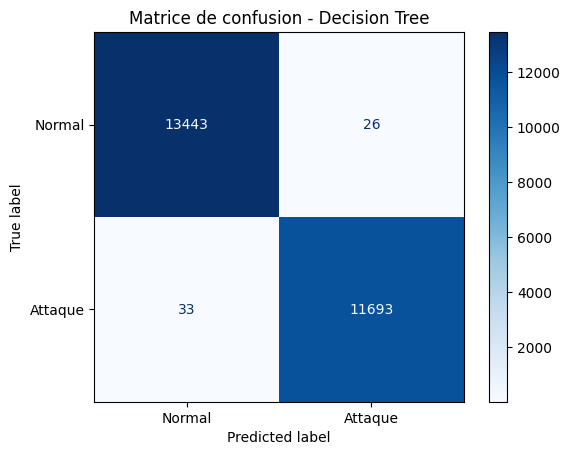

In [46]:
evaluer_et_afficher(DecisionTreeClassifier(random_state=42), "Decision Tree", X_train_bin, X_test_bin, y_train_bin, y_test_bin)

### 4.1.5 Autres modèles supervisés à tester
📌 Tous ces modèles utilisent la même fonction evaluer_modele_binaire() définie précédemment.


🔍 Évaluation du modèle : Random Forest
----------------------------------------
Accuracy  : 0.9991
Precision : 0.9996
Recall    : 0.9985
F1 Score  : 0.9990

Rapport de classification :
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
     Attaque       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



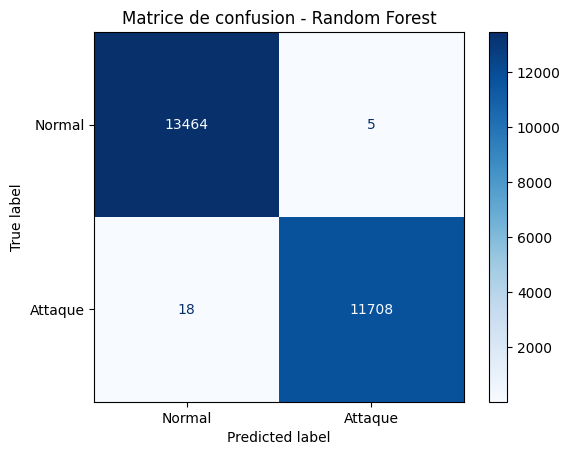

In [47]:
evaluer_et_afficher(RandomForestClassifier(random_state=42), "Random Forest", X_train_bin, X_test_bin, y_train_bin, y_test_bin)

###  Naive Bayes


🔍 Évaluation du modèle : Naive Bayes
----------------------------------------
Accuracy  : 0.8944
Precision : 0.8649
Recall    : 0.9162
F1 Score  : 0.8898

Rapport de classification :
              precision    recall  f1-score   support

      Normal       0.92      0.88      0.90     13469
     Attaque       0.86      0.92      0.89     11726

    accuracy                           0.89     25195
   macro avg       0.89      0.90      0.89     25195
weighted avg       0.90      0.89      0.89     25195



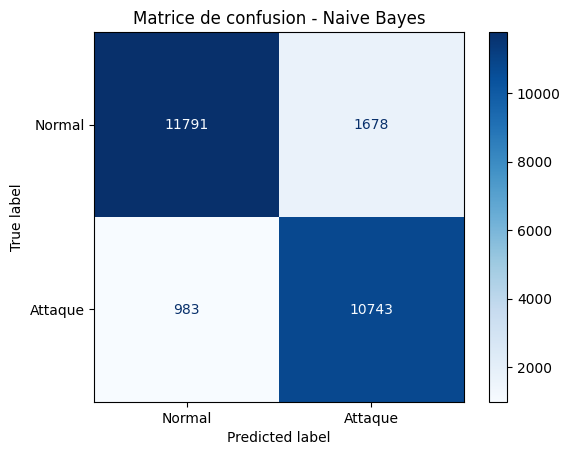

In [48]:
evaluer_et_afficher(GaussianNB(), "Naive Bayes", X_train_bin, X_test_bin, y_train_bin, y_test_bin)

### Support Vector Machine (SVM)


🔍 Évaluation du modèle : SVM
----------------------------------------
Accuracy  : 0.9922
Precision : 0.9930
Recall    : 0.9902
F1 Score  : 0.9916

Rapport de classification :
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     13469
     Attaque       0.99      0.99      0.99     11726

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195



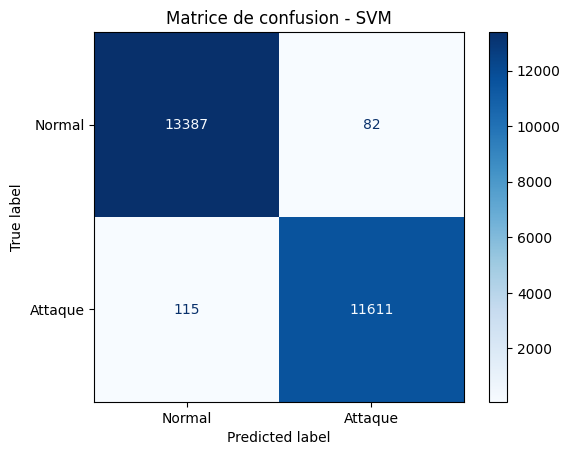

In [49]:
evaluer_et_afficher(SVC(kernel='rbf', C=1, gamma='scale'), "SVM", X_train_bin, X_test_bin, y_train_bin, y_test_bin)

### AdaBoost


🔍 Évaluation du modèle : AdaBoost
----------------------------------------
Accuracy  : 0.9825
Precision : 0.9876
Recall    : 0.9746
F1 Score  : 0.9810

Rapport de classification :
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98     13469
     Attaque       0.99      0.97      0.98     11726

    accuracy                           0.98     25195
   macro avg       0.98      0.98      0.98     25195
weighted avg       0.98      0.98      0.98     25195



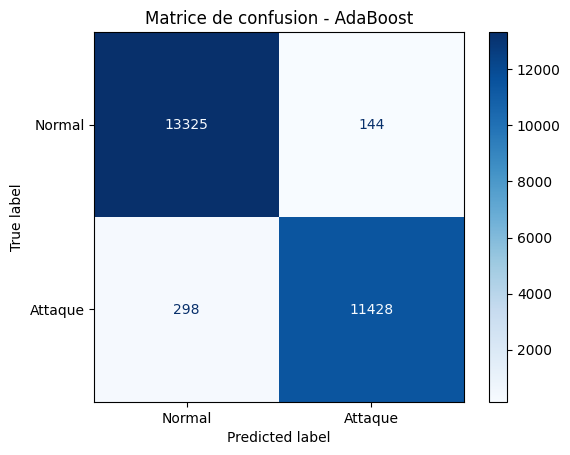

In [50]:
evaluer_et_afficher(AdaBoostClassifier(n_estimators=100, random_state=42), "AdaBoost", X_train_bin, X_test_bin, y_train_bin, y_test_bin)

### Gradient Boosting


🔍 Évaluation du modèle : Gradient Boosting
----------------------------------------
Accuracy  : 0.9966
Precision : 0.9973
Recall    : 0.9954
F1 Score  : 0.9963

Rapport de classification :
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
     Attaque       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



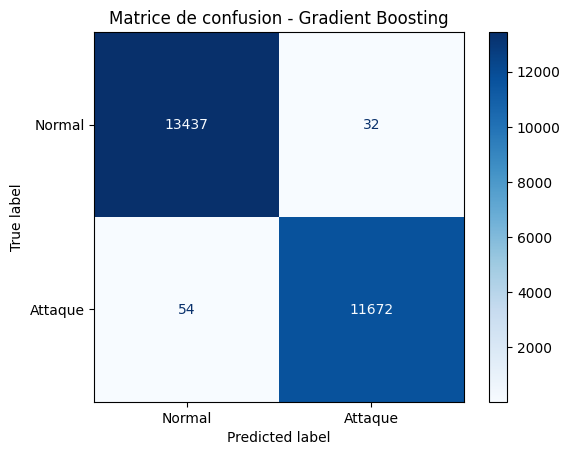

In [51]:
evaluer_et_afficher(GradientBoostingClassifier(n_estimators=100, random_state=42), "Gradient Boosting", X_train_bin, X_test_bin, y_train_bin, y_test_bin)

### Multi-Layer Perceptron (MLP)


🔍 Évaluation du modèle : MLP
----------------------------------------
Accuracy  : 0.9965
Precision : 0.9978
Recall    : 0.9948
F1 Score  : 0.9963

Rapport de classification :
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
     Attaque       1.00      0.99      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



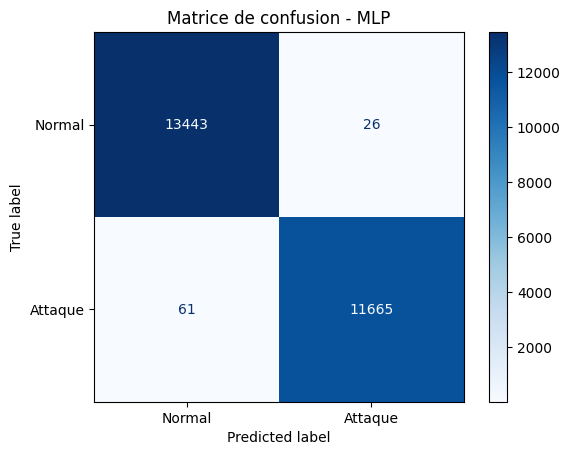

In [52]:
evaluer_et_afficher(MLPClassifier(hidden_layer_sizes=(100,), activation='relu', max_iter=300, random_state=42),
                    "MLP", X_train_bin, X_test_bin, y_train_bin, y_test_bin)

## Étape 4.2 – Classification binaire avec Autoencoder (Unsupervised)
🎯 Objectif :
L’autoencoder est entraîné uniquement sur des échantillons normaux, et il apprend à les reconstruire. Ensuite, les anomalies (attaques) sont détectées par un taux d’erreur de reconstruction élevé.

In [53]:
# Reconstruction
reconstructions = autoencoder.predict(X_test_bin)
mse = np.mean(np.power(X_test_bin - reconstructions, 2), axis=1)

# Seuil basé sur le 95e percentile
seuil = np.percentile(mse, 95)
y_pred_autoenc = (mse > seuil).astype(int)

# Métriques
acc = accuracy_score(y_test_bin, y_pred_autoenc)
prec = precision_score(y_test_bin, y_pred_autoenc)
rec = recall_score(y_test_bin, y_pred_autoenc)
f1 = f1_score(y_test_bin, y_pred_autoenc)

print("\n🤖 Évaluation - Autoencoder (non supervisé)")
print("-" * 40)
print(f"Seuil de détection utilisé : {seuil:.6f}")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nRapport de classification :")
print(classification_report(y_test_bin, y_pred_autoenc, target_names=['Normal', 'Attaque']))

ConfusionMatrixDisplay.from_predictions(y_test_bin, y_pred_autoenc, display_labels=['Normal', 'Attaque'], cmap='Blues')
plt.title("Matrice de confusion - Autoencoder")
plt.show()

# Sauvegarde
resultats_models_binaires.append({
    'Model': 'Autoencoder',
    'Accuracy': acc * 100,
    'Precision': prec * 100,
    'Recall': rec * 100,
    'F1 Score': f1
})


NameError: name 'autoencoder' is not defined

## Etape 4.3 : Affichage final du tableau

In [ ]:
# Tableau final avec mise en forme
df_resultats_binaires = pd.DataFrame(resultats_models_binaires).round(2)

def highlight_max(s):
    return ['font-weight: bold' if v == s.max() else '' for v in s]

df_resultats_binaires.style.apply(highlight_max, subset=['Accuracy', 'Precision', 'Recall', 'F1 Score'])


## Étape 5 – Classification Multi-Classes (4 types d’attaques)

Objectif : Identifier précisément le type d’attaque :
→ DoS, Probe, R2L, U2R
(selon le schéma de l’article, après la détection binaire)

Objectif : Classifier les attaques détectées en 4 types :
DoS, Probe, R2L, U2R
en testant avec et sans oversampling (SVM-SMOTE), comme dans TABLE III de l’article.


### 5.1 – Préparation des données d’attaque uniquement

In [ ]:
# Sélection des échantillons où l'étiquette ≠ normal
X_multi = X_scaled[y != 'normal']
y_multi = y[y != 'normal']  # y contient les types : DoS, Probe, R2L, U2R

print("Répartition initiale des attaques :")
print(y_multi.value_counts())


###  5.2 – Encodage des 4 classes d'attaque

In [ ]:
label_encoder = LabelEncoder()
y_multi_encoded = label_encoder.fit_transform(y_multi)

# Sauvegarder l'ordre des classes pour l'affichage
classes = label_encoder.classes_
print("Mapping des classes :", dict(zip(classes, range(len(classes)))))

 ### 5.3 – Séparer les données pour les deux cas (avec / sans SMOTE)

Objectif :
- Rééquilibrer les classes d’attaque (très déséquilibrées, surtout U2R et R2L).

In [ ]:
# 80% train / 20% test, stratifié
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi_encoded, test_size=0.2, stratify=y_multi_encoded, random_state=42
)

# Copie sans oversampling pour comparaison
X_train_no_smote = X_train_multi.copy()
y_train_no_smote = y_train_multi.copy()

### 5.4 – Appliquer SVM-SMOTE (avec oversampling)
Ce modèle est utilisé pour classifier les attaques en 4 types :
DoS, Probe, R2L, U2R (après oversampling avec SVM-SMOTE)

In [ ]:
smote = SVMSMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_multi, y_train_multi)

print("Répartition après SVM-SMOTE :", Counter(y_train_smote))

### 5.5 – Entraînement du MLP (modèle commun)

In [ ]:
def entrainer_mlp(X_train, y_train):
    mlp = MLPClassifier(hidden_layer_sizes=(80,), activation='relu', max_iter=300, random_state=42)
    mlp.fit(X_train, y_train)
    return mlp


### 5.6 – Évaluer avec et sans SMOTE

In [ ]:
# === Sans SMOTE ===
mlp_no_smote = entrainer_mlp(X_train_no_smote, y_train_no_smote)
y_pred_no_smote = mlp_no_smote.predict(X_test_multi)
report_no = classification_report(y_test_multi, y_pred_no_smote, output_dict=True, zero_division=0)

# === Avec SMOTE ===
mlp_smote = entrainer_mlp(X_train_smote, y_train_smote)
y_pred_smote = mlp_smote.predict(X_test_multi)
report_smote = classification_report(y_test_multi, y_pred_smote, output_dict=True, zero_division=0)


### 5.7 – Générer le tableau de comparaison (comme TABLE III)

In [ ]:
# Résumé des métriques par classe
table_comparaison = pd.DataFrame({
    'w/o Oversampling': {
        'Accuracy': accuracy_score(y_test_multi, y_pred_no_smote) * 100,
        'F1_DoS': report_no['0']['f1-score'],
        'F1_Probe': report_no['1']['f1-score'],
        'F1_R2L': report_no['2']['f1-score'],
        'F1_U2R': report_no['3']['f1-score'],
        'Macro F1': f1_score(y_test_multi, y_pred_no_smote, average='macro'),
        'Micro F1': f1_score(y_test_multi, y_pred_no_smote, average='micro')
    },
    'w/ Oversampling': {
        'Accuracy': accuracy_score(y_test_multi, y_pred_smote) * 100,
        'F1_DoS': report_smote['0']['f1-score'],
        'F1_Probe': report_smote['1']['f1-score'],
        'F1_R2L': report_smote['2']['f1-score'],
        'F1_U2R': report_smote['3']['f1-score'],
        'Macro F1': f1_score(y_test_multi, y_pred_smote, average='macro'),
        'Micro F1': f1_score(y_test_multi, y_pred_smote, average='micro')
    }
}).round(4)

# Affichage
table_comparaison

### 5.8 – Matrice de confusion normalisée

In [ ]:
# Matrice normalisée (avec SMOTE)
cm = confusion_matrix(y_test_multi, y_pred_smote, normalize='true')

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Matrice de confusion normalisée - Classification 4 classes")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


## Étape 6 – Mise en production / prédiction sur de nouvelles données

### Étape 6.1 – Charger et prétraiter les nouvelles données
tester manuellement :

### Exemple 1 : prédire une ligne manuelle

In [ ]:
# Exemple : connexion réseau (avec les 41 features dans le bon ordre)
nouvelle_connexion = pd.DataFrame([[
    0, 'tcp', 'http', 'SF', 181, 5450, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9,
    9, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 9, 9, 1.0, 0.0, 0.11, 0.0, 0.0, 0.0, 0.0, 0.0
]], columns=X.columns)  # X.columns doit contenir les noms originaux

###  Prétraitement (à refaire pour les nouvelles données)

In [ ]:
# Encodage des variables catégorielles
for col in ['type_protocole', 'service', 'drapeau']:
    nouvelle_connexion[col] = LabelEncoder().fit(X[col]).transform(nouvelle_connexion[col])

# Normalisation (avec le scaler déjà entraîné sur X_scaled)
nouvelle_connexion_scaled = scaler.transform(nouvelle_connexion)

### Étape 6.2 – Prédiction binaire : normal vs attaque

#### Utiliser le meilleur modèle binaire (ex : autoencoder ou MLP/SVM)

In [ ]:
# Avec autoencoder
recon = autoencoder.predict(nouvelle_connexion_scaled)
erreur = np.mean(np.power(nouvelle_connexion_scaled - recon, 2), axis=1)
est_une_attaque = erreur > seuil

if est_une_attaque[0]:
    print("🔺 Prédiction : ATTACK détectée")
else:
    print("✅ Prédiction : COMPORTEMENT NORMAL")

#### Ou avec un classifieur supervisé binaire (ex: RandomForest)

In [ ]:
prediction_bin = clf_rf.predict(nouvelle_connexion_scaled)
print("🔺 Attack" if prediction_bin[0] == 1 else "✅ Normal")

### Étape 6.3 – Si attaque → prédire son type (DoS, Probe, etc.)

In [ ]:
if est_une_attaque[0]:  # ou si prediction_bin[0] == 1
    prediction_type = mlp_smote.predict(nouvelle_connexion_scaled)
    type_attaque = label_encoder.inverse_transform(prediction_type)
    print(f"🧠 Type d’attaque prédit : {type_attaque[0]}")